# Breit-Wigner Function Exercise

Understand how to use (non-relativistic) Breit-Wigner (BW) function (use ROOT library! check ROOT documentation) with $m=90$ and $\Gamma=2$. Generate $10^6$ events from B-W probability density distribution and fill a histogram.

- Plot B-W distribution function in reasonable range and plot properly scaled histogram with reasonable binning on the same picture.
- Fit B-W function to generated points. Plot fitted function with different color on the same plot.
- Do not forget to add legend and mark axes.

Generated 1000000 events. Histogram has 1000000.0 entries.
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1108.12
NDf                       =          997
Edm                       =  6.45798e-08
NCalls                    =          105
p0                        =        39951   +/-   40.6705     
p1                        =           90   +/-   0.00141376  
p2                        =      1.99637   +/-   0.00291974  


Warning in <TROOT::Append>: Replacing existing TH1: hBW (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: cBW


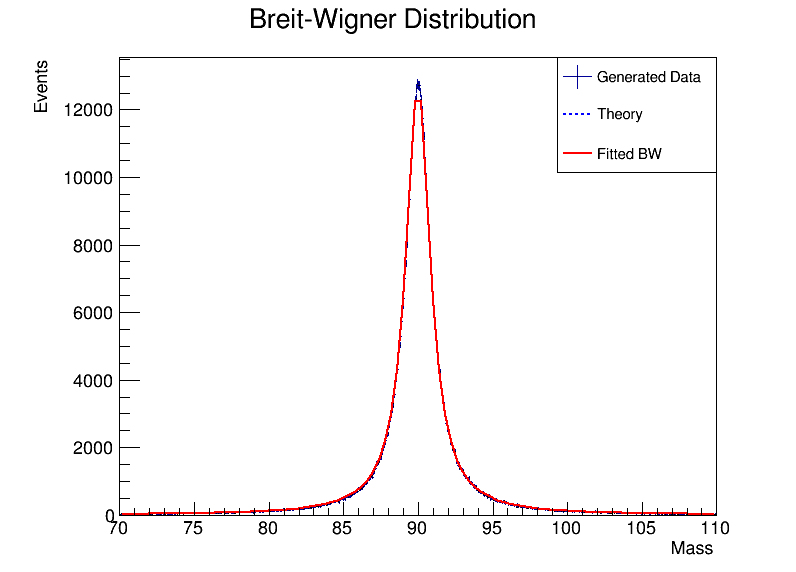

In [65]:
from ROOT import TH1D, gRandom

m = 90
gamma = 2
nEvents = int(1e6)

gRandom.SetSeed(12345)
hBW = TH1D('hBW', 'Breit-Wigner Distribution; Mass; Events', 1000, 70., 110.)
# hDistZ = ROOT.TH1D('hDistZ','hDistZ',100, 0., 20.)
hBW.Sumw2()

#events
for i in range(nEvents):
    x = gRandom.BreitWigner(m, gamma)
    hBW.Fill(x)

print(f"Generated {nEvents} events. Histogram has {hBW.GetEntries()} entries.")
hBW.SetStats(0)
hBW.DrawCopy() 


# g1 = ROOT.TF1("g1", "gaus",70,110 )
# sigmaGauss = 1.
# g1.SetParameter(0, 1./sigmaGauss/math.sqrt(2*math.pi) )
# g1.SetParameter(1,5.)
# g1.SetParameter(2,sigmaGauss)
# hBW.Fit(g1)

#fit
g2 = ROOT.TF1("g2", "breitwigner",70,110 )
g2.SetParameter(0, 0.)
g2.SetParameter(1, 90.)
g2.SetParameter(2, 2.)
hBW.Fit(g2)

#theory
theory_func = ROOT.TF1("theory", "breitwigner", 70, 110)
theory_func.SetParameters(1000, m, gamma)
theory_func.SetLineColor(ROOT.kBlue)
theory_func.SetLineStyle(2)
theory_func.Draw("same")


hBW.DrawCopy('same')
c = TCanvas('cBW', 'Breit-Wigner Histogram', 800, 600)
hBW.Draw()

#legend
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
legend.AddEntry(hBW, "Generated Data", "lep")
legend.AddEntry(theory_func, "Theory", "l")
legend.AddEntry(g2, "Fitted BW", "l")
legend.Draw()

c.SetLeftMargin(0.15)  #Space for printing Y label



c.Draw()

# cFitG.Draw()